# NB17 — Quantile Regression

> **StatQuest: "OLS models the average. Quantile regression models the median — or any percentile."**

---

## The main ideas:

1. OLS models E[y|x] — the **conditional mean**
2. Quantile regression models Q_tau[y|x] — the conditional **tau-th quantile**
3. tau=0.5 -> median (robust to outliers); tau=0.9 -> 90th percentile
4. Uses **pinball loss** (asymmetric): penalises over-prediction more or less depending on tau
5. Gives you natural **prediction intervals** without assuming normality


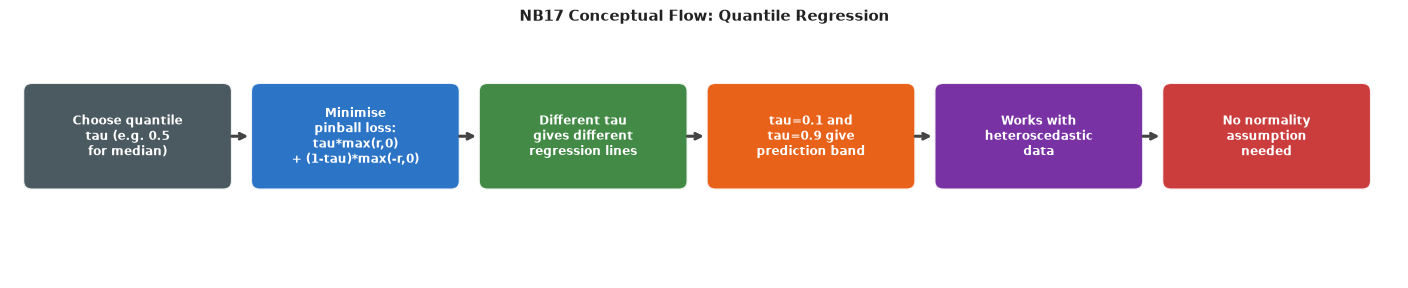

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Choose quantile\ntau (e.g. 0.5\nfor median)',
        'Minimise\npinball loss:\ntau*max(r,0)\n+ (1-tau)*max(-r,0)',
        'Different tau\ngives different\nregression lines',
        'tau=0.1 and\ntau=0.9 give\nprediction band',
        'Works with\nheteroscedastic\ndata',
        'No normality\nassumption\nneeded',
    ],
    title='NB17 Conceptual Flow: Quantile Regression',
    colors=['#37474F','#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828'],
)


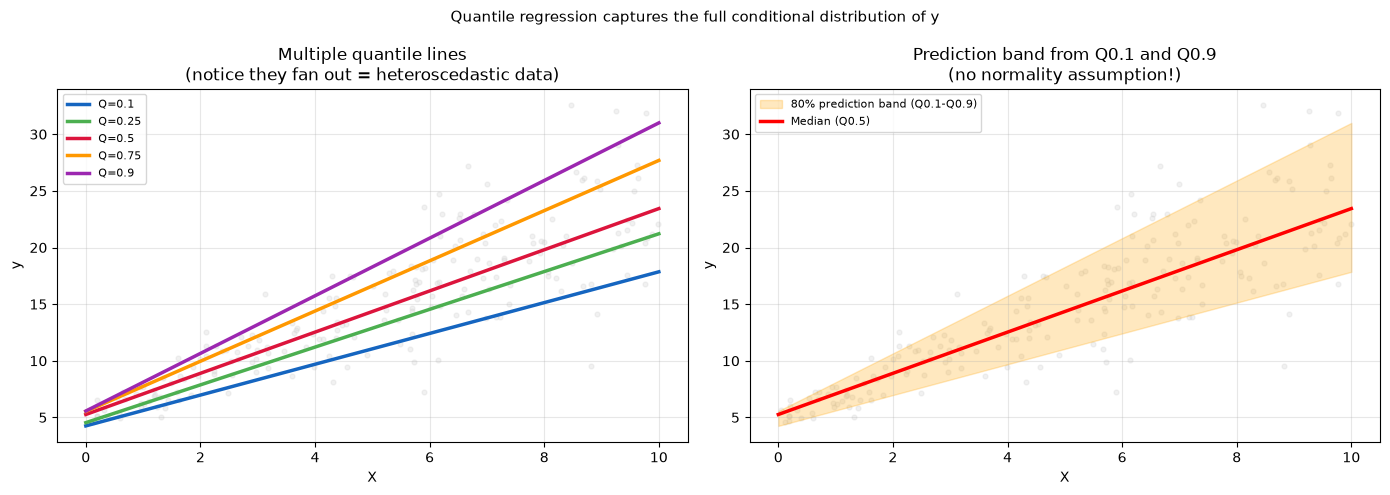

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import QuantileRegressor

np.random.seed(0)
n = 200
X = np.sort(np.random.uniform(0, 10, n))
y = 2*X + 5 + np.random.normal(0, 0.5*X + 0.5, n)   # heteroscedastic

X_2d   = X.reshape(-1,1)
X_plot = np.linspace(0, 10, 200).reshape(-1,1)

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
line_colors = ['#1565C0','#4CAF50','crimson','#FF9800','#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all quantile lines
ax = axes[0]
ax.scatter(X, y, s=12, alpha=0.3, color='lightgray')
for q, col in zip(quantiles, line_colors):
    qr = QuantileRegressor(quantile=q, alpha=0, solver='highs').fit(X_2d, y)
    ax.plot(X_plot, qr.predict(X_plot), color=col, linewidth=2.5, label=f'Q={q}')
ax.set_xlabel('X'); ax.set_ylabel('y')
ax.set_title('Multiple quantile lines\n(notice they fan out = heteroscedastic data)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: prediction interval
qr_lo = QuantileRegressor(quantile=0.1, alpha=0, solver='highs').fit(X_2d, y)
qr_md = QuantileRegressor(quantile=0.5, alpha=0, solver='highs').fit(X_2d, y)
qr_hi = QuantileRegressor(quantile=0.9, alpha=0, solver='highs').fit(X_2d, y)

ax = axes[1]
ax.scatter(X, y, s=12, alpha=0.3, color='lightgray')
ax.fill_between(X_plot.ravel(), qr_lo.predict(X_plot), qr_hi.predict(X_plot),
                alpha=0.25, color='orange', label='80% prediction band (Q0.1-Q0.9)')
ax.plot(X_plot, qr_md.predict(X_plot), 'r-', linewidth=2.5, label='Median (Q0.5)')
ax.set_xlabel('X'); ax.set_ylabel('y')
ax.set_title('Prediction band from Q0.1 and Q0.9\n(no normality assumption!)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Quantile regression captures the full conditional distribution of y',
             fontsize=11)
plt.tight_layout(); plt.show()


## When to use Quantile Regression

| Scenario | Why quantile regression helps |
|---------|------------------------------|
| Skewed outcome (e.g. income) | Median more meaningful than mean |
| Heteroscedastic data | Captures how spread changes with x |
| Outliers in y | Median regression is robust |
| Need prediction intervals | Q0.1 and Q0.9 directly give 80% band |
| Care about extremes | Model Q0.95 directly for risk/SLA purposes |

**Next: NB18 — Bayesian linear regression (get a full distribution over coefficients).**
